In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [24]:
df =  pd.read_csv("/content/cleaned_data.csv")
print("shape:",df.shape)
df.head()

shape: (11971, 11)


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False


In [25]:
print(df[["price_per_unit","quantity","total_spent"]].describe())


print("\nUnique categories:", df["category"].nunique())
print("Unique items:", df["item"].nunique())
print("Unique payment methods:", df["payment_method"].unique())
print("Unique locations:", df["location"].unique())


       price_per_unit      quantity   total_spent
count    11971.000000  11971.000000  11971.000000
mean        23.360872      5.536380    129.652577
std         10.741889      2.857883     94.750697
min          5.000000      1.000000      5.000000
25%         14.000000      3.000000     51.000000
50%         23.000000      6.000000    108.500000
75%         33.500000      8.000000    192.000000
max         41.000000     10.000000    410.000000

Unique categories: 8
Unique items: 201
Unique payment methods: ['Digital Wallet' 'Credit Card' 'Cash']
Unique locations: ['Online' 'In-store']


In [26]:
category_sales = df.groupby("category")["total_spent"].sum().sort_values(ascending=False)
print(category_sales)

category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: total_spent, dtype: float64


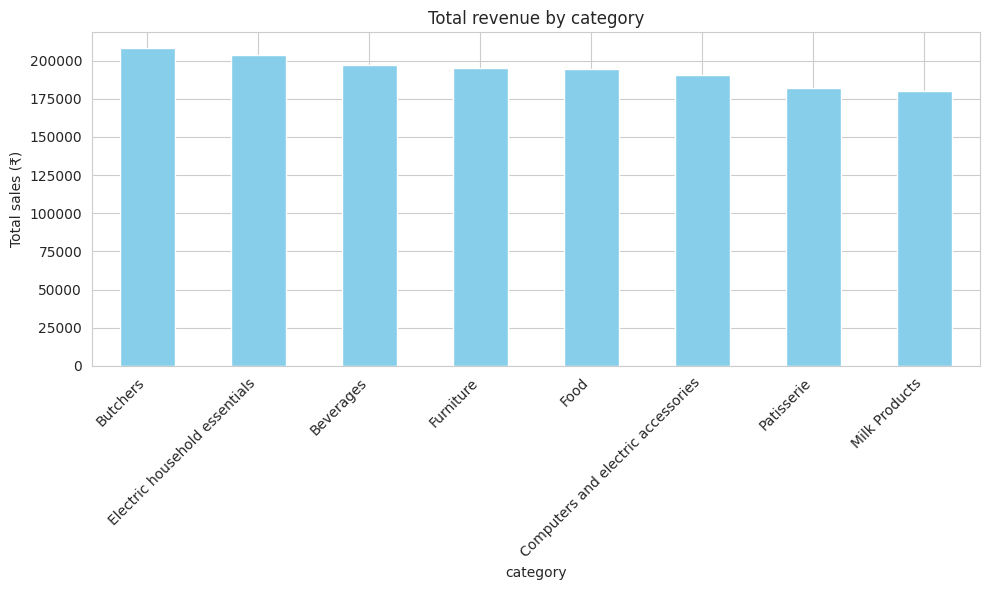

In [27]:
plt.figure(figsize=(10,6))
category_sales.plot(kind="bar",color="skyblue")
plt.title("Total revenue by category")
plt.xlabel("category")
plt.ylabel("Total sales (₹)")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [28]:
location_sales = df.groupby("location")["total_spent"].agg(["sum", "mean", "count"])
location_sales.columns = ["total_revenue", "avg_transaction_value", "num_transactions"]
print(location_sales)

          total_revenue  avg_transaction_value  num_transactions
location                                                        
In-store       760670.0             128.861596              5903
Online         791401.0             130.422050              6068


payment_method
Cash              4103
Digital Wallet    3941
Credit Card       3927
Name: count, dtype: int64


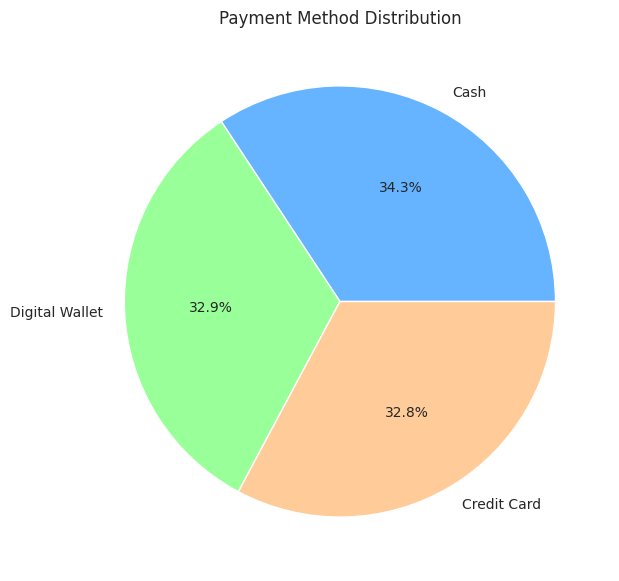

In [29]:
payment_counts = df["payment_method"].value_counts()
print(payment_counts)

plt.figure(figsize=(7,7))
plt.pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%", colors=["#66b3ff","#99ff99","#ffcc99"])
plt.title("Payment Method Distribution")
plt.show()

month
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: total_spent, dtype: float64


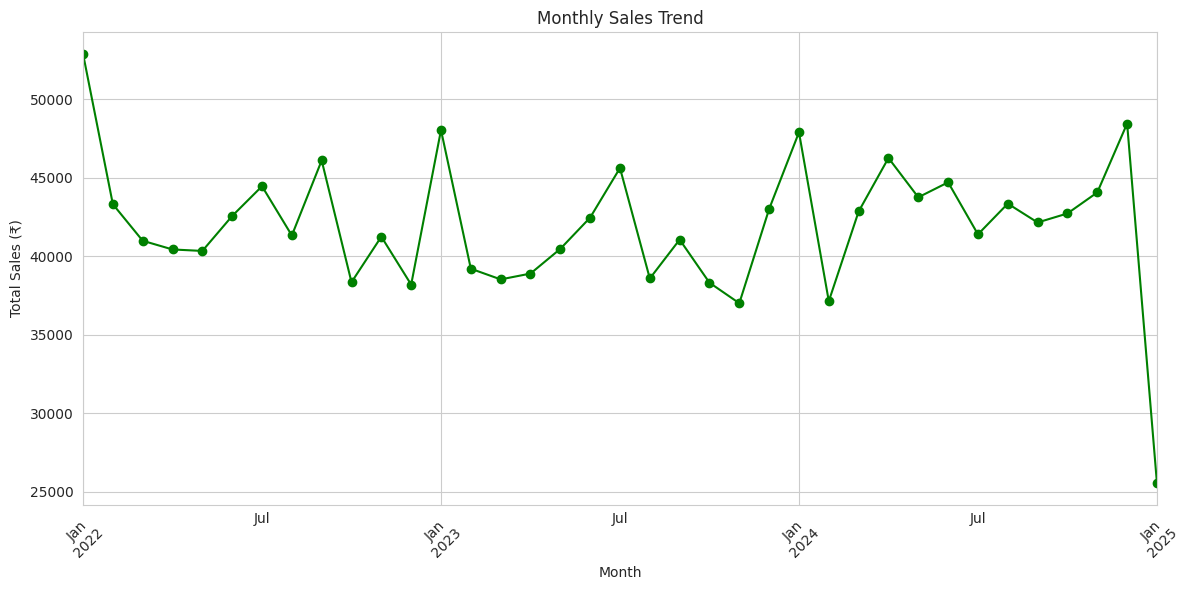

In [30]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["month"] = df["transaction_date"].dt.to_period("M")

monthly_sales = df.groupby("month")["total_spent"].sum()
print(monthly_sales)

plt.figure(figsize=(12,6))
monthly_sales.plot(kind="line", marker="o", color="green")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

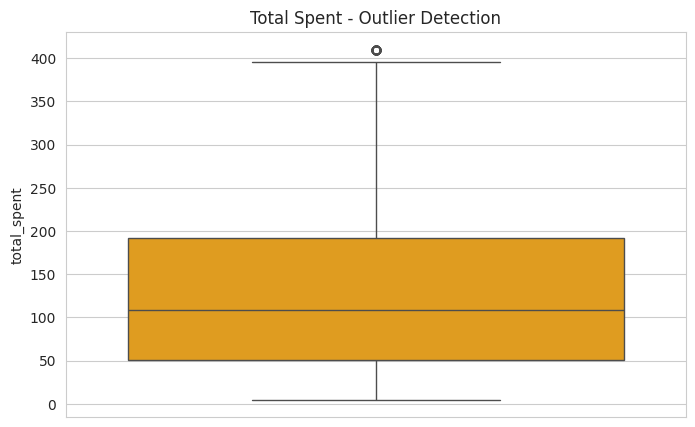

Number of outlier transactions: 60
Normal range:  -160.5 to 403.5


,transaction_id,category,total_spent
23,TXN_1599706,Furniture,410.0
124,TXN_2953434,Furniture,410.0
319,TXN_4374445,Food,410.0
830,TXN_1814138,Beverages,410.0
1010,TXN_3710081,Furniture,410.0
1036,TXN_1273334,Beverages,410.0
1401,TXN_1938135,Butchers,410.0
1435,TXN_8520397,Electric household essentials,410.0
1497,TXN_8048041,Butchers,410.0
1865,TXN_1860120,Furniture,410.0


In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["total_spent"], color="orange")
plt.title("Total Spent - Outlier Detection")
plt.show()

Q1 = df["total_spent"].quantile(0.25)
Q3 = df["total_spent"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["total_spent"] < lower) | (df["total_spent"] > upper)]
print("Number of outlier transactions:", len(outliers))
print("Normal range: ", lower, "to", upper)
outliers[["transaction_id", "category", "total_spent"]].head(10)

item
Item_2_BEV      676
Item_16_MILK    627
Item_25_FUR     616
Item_19_MILK    589
Item_5_FUR      581
Item_13_FOOD    581
Item_1_MILK     578
Item_11_MILK    574
Item_11_FUR     573
Item_14_FOOD    566
Name: quantity, dtype: int64


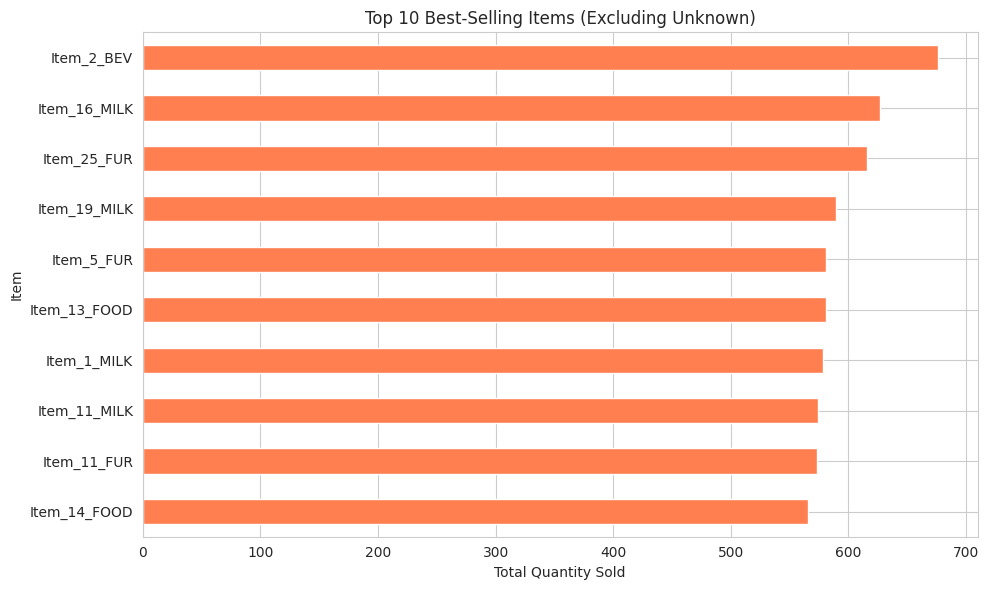

In [32]:
top_items = df[df["item"] != "Unknown"].groupby("item")["quantity"].sum().sort_values(ascending=False).head(10)
print(top_items)

plt.figure(figsize=(10,6))
top_items.plot(kind="barh", color="coral")
plt.title("Top 10 Best-Selling Items (Excluding Unknown)")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Item")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

                  avg_transaction_value  num_transactions
discount_applied                                         
False                        129.953330              3964
True                         130.491043              4019


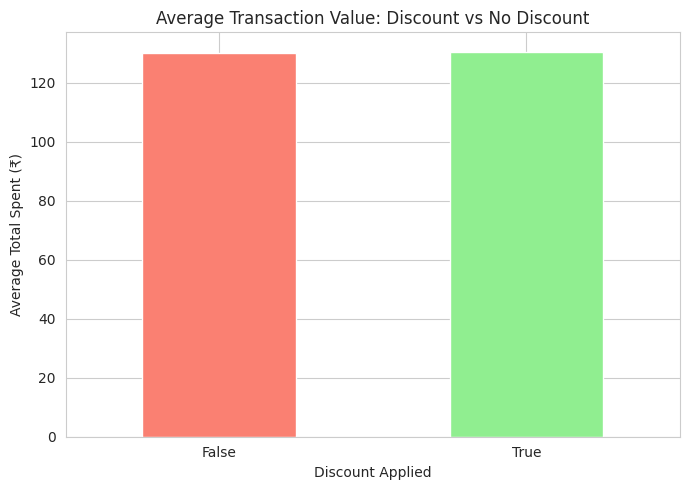

In [33]:
discount_impact = df.groupby("discount_applied")["total_spent"].agg(["mean", "count"])
discount_impact.columns = ["avg_transaction_value", "num_transactions"]
print(discount_impact)

plt.figure(figsize=(7,5))
discount_impact["avg_transaction_value"].plot(kind="bar", color=["salmon","lightgreen"])
plt.title("Average Transaction Value: Discount vs No Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Average Total Spent (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()